# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

**Fecha:** 23 de Mayo de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie usando una arquitectura pre-entrenada UNet

## 1. Importe de librerias

In [3]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

import os
import zipfile
import shutil
!pip install seaborn
import seaborn as sns
import datetime
!pip install opencv-python
import cv2


import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, concatenate, GlobalAveragePooling2D

!pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [4]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-05-23 05:13:13.867285


## 2. Definción de Rutas y Parámetros

In [6]:
data_dir = 'Datos Finales Estado Balanceados'  # Reemplaza con la ruta real
metadata_file = 'archivos_datos_balanceados_estado.csv' # Reemplaza con la ruta real
image_height = 128
image_width = 128
batch_size = 32
num_classes = None  # Se determinará automáticamente del archivo CSV

## 3. Cargar y procesar los metadatos

In [8]:
try:
    metadata = pd.read_csv(metadata_file, sep=";")
    metadata = metadata.rename(columns={'Nombre del archivo': 'image_id'})
    metadata = metadata.rename(columns={'Planta_Estado': 'Planta_Estado_Español'})
    
    # Asegúrate de que las columnas 'filename' (o el nombre de tu columna de nombres de archivo)
    # y 'label' (o el nombre de tu columna de etiquetas) existan.
   
    if 'image_id' not in metadata.columns or 'Planta_Estado_Español' not in metadata.columns:
        raise ValueError("El archivo CSV debe contener las columnas 'image_id' y 'Planta_Estado_Español'.")
    class_names = metadata['Planta_Estado_Español'].unique().tolist()
    num_classes = len(class_names)
    print(f"Se encontraron {num_classes} clases: {class_names}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo de metadatos en '{metadata_file}'.")
    exit()
except ValueError as e:
    print(f"Error al procesar el archivo CSV: {e}")
    exit()

Se encontraron 18 clases: ['Maíz_Enferma', 'Tomate_Saludable', 'Yuca_Enferma', 'Pepino Cohombro_Enferma', 'Tomate_Enferma', 'Manzana_Saludable', 'Fresa_Enferma', 'Maíz_Saludable', 'Papa_Enferma', 'Fresa_Saludable', 'Coliflor_Enferma', 'Pepino Cohombro_Saludable', 'Yuca_Saludable', 'Fríjol_Enferma', 'Papa_Saludable', 'Fríjol_Saludable', 'Coliflor_Saludable', 'Manzana_Enferma']


In [12]:
metadata.Planta_Estado_Español.value_counts()

Planta_Estado_Español
Fríjol_Saludable             3501
Maíz_Enferma                 3500
Tomate_Saludable             3500
Coliflor_Saludable           3500
Papa_Saludable               3500
Fríjol_Enferma               3500
Yuca_Saludable               3500
Pepino Cohombro_Saludable    3500
Coliflor_Enferma             3500
Fresa_Saludable              3500
Papa_Enferma                 3500
Maíz_Saludable               3500
Fresa_Enferma                3500
Manzana_Saludable            3500
Tomate_Enferma               3500
Pepino Cohombro_Enferma      3500
Yuca_Enferma                 3500
Manzana_Enferma              3500
Name: count, dtype: int64

In [15]:
train, test= train_test_split(metadata, test_size=0.2, random_state=42,shuffle=True, stratify=metadata['Planta_Estado_Español'])
train.shape, test.shape

((50400, 7), (12601, 7))

In [17]:
train.head()

,Carpeta,image_id,Planta_Inglés,Estado_Ingles,Planta_Español,Estado_Español,Planta_Estado_Español
50219,Potato_healthy,aug_966_683b04ad-7941-4819-9965-ba32c725eb22__...,Potato,healthy,Papa,Saludable,Papa_Saludable
12719,Cucumber_sick,aug_60_cucumber_photo_2020-06-27_23-51-02 (2).jpg,Cucumber,sick,Pepino Cohombro,Enferma,Pepino Cohombro_Enferma
23065,Strawberry_sick,aug_124_36bc7257-0b59-45a9-a692-1ff35b5a3425__...,Strawberry,sick,Fresa,Enferma,Fresa_Enferma
42154,Cassava_healthy,aug_799_919479322.jpg,Cassava,healthy,Yuca,Saludable,Yuca_Saludable
60493,Apple_sick,b1a2c1e8-e1a6-4d25-9d5b-1488e9d8b0ee___FREC_C....,Apple,sick,Manzana,Enferma,Manzana_Enferma


In [19]:
sample = train.sample(5)  # ejemplo común
print(sample)

                  Carpeta                                           image_id  \
29389         Potato_sick  1757f48b-435b-4c4a-9de6-47b959ed1e67___RS_LB 5...   
34517  Strawberry_healthy  73cc96dc-59d4-4a43-91ed-8286de00beea___RS_HL 4...   
8830         Cassava_sick                                      442179764.jpg   
6035       Tomato_healthy  aug_1717_7a73a7f9-27e3-4898-be48-97ddcaa094a4_...   
28467         Potato_sick  aug_746_159f49c5-8d80-41cb-b730-333fdefdff62__...   

      Planta_Inglés Estado_Ingles Planta_Español Estado_Español  \
29389        Potato          sick           Papa        Enferma   
34517    Strawberry       healthy          Fresa      Saludable   
8830        Cassava          sick           Yuca        Enferma   
6035         Tomato       healthy         Tomate      Saludable   
28467        Potato          sick           Papa        Enferma   

      Planta_Estado_Español  
29389          Papa_Enferma  
34517       Fresa_Saludable  
8830           Yuca_Enferm

In [21]:
print(sample.columns)

Index(['Carpeta', 'image_id', 'Planta_Inglés', 'Estado_Ingles',
       'Planta_Español', 'Estado_Español', 'Planta_Estado_Español'],
      dtype='object')


## 4. Crear un generador de datos

In [24]:
df_subset = train.sample(frac=1, random_state=42)  # Solo 50% de los datos para entrenamiento rápido
df_subset.head()

,Carpeta,image_id,Planta_Inglés,Estado_Ingles,Planta_Español,Estado_Español,Planta_Estado_Español
1746,Corn_sick,bc43c710-9fa2-44a2-8420-94c71c01c2c6___RS_GLSp...,Corn,sick,Maíz,Enferma,Maíz_Enferma
30848,Potato_sick,aug_770_31d5d932-9eb3-45d1-bc85-40ef64d7a688__...,Potato,sick,Papa,Enferma,Papa_Enferma
15267,Tomato_sick,ed85b79f-958f-42a8-adb9-2a34022fa016___Crnl_L....,Tomato,sick,Tomate,Enferma,Tomate_Enferma
21171,Strawberry_sick,aug_572_2f54dce1-5aa1-43fb-8eb4-8aeb18419440__...,Strawberry,sick,Fresa,Enferma,Fresa_Enferma
48779,Bean_sick,aug_1732_bean_bean_rust_train.278.jpg,Bean,sick,Fríjol,Enferma,Fríjol_Enferma


In [26]:
df_subset.shape

(50400, 7)

In [28]:
# Crear el generador de imágenes
datagen = ImageDataGenerator(
    validation_split = 0.2,
    rescale=1./255
)

train_generator = datagen.flow_from_dataframe(
    dataframe=df_subset,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Estado_Español',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training'
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=df_subset,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Estado_Español',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 40320 validated image filenames belonging to 18 classes.
Found 10079 validated image filenames belonging to 18 classes.


In [29]:
print(train['Planta_Estado_Español'].value_counts())
print(f"Total clases: {train['Planta_Estado_Español'].nunique()}")


Planta_Estado_Español
Papa_Saludable               2800
Pepino Cohombro_Enferma      2800
Tomate_Saludable             2800
Papa_Enferma                 2800
Maíz_Saludable               2800
Fríjol_Enferma               2800
Coliflor_Enferma             2800
Pepino Cohombro_Saludable    2800
Fríjol_Saludable             2800
Manzana_Saludable            2800
Coliflor_Saludable           2800
Yuca_Enferma                 2800
Tomate_Enferma               2800
Fresa_Saludable              2800
Manzana_Enferma              2800
Yuca_Saludable               2800
Fresa_Enferma                2800
Maíz_Enferma                 2800
Name: count, dtype: int64
Total clases: 18


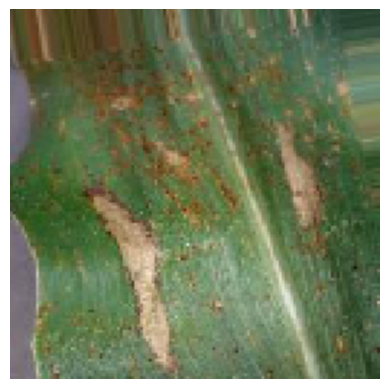

In [30]:
from tensorflow.keras.preprocessing import image
import os
import numpy as np

img_path = os.path.join(data_dir, metadata["image_id"][45])
img = image.load_img(img_path, target_size=(image_height, image_width))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

plt.imshow(img_tensor[0])
plt.axis('off')
plt.show()

## 5. Definición del modelo U-Net para clasificación

In [32]:
epochs=15
steps_per_epoch = len(train)*0.8 / batch_size
validation_steps = len(train)*0.2 / batch_size

In [33]:
# DEFINIR EL MODELO U-NET MODIFICADO PARA CLASIFICACIÓN
def unet_classification_model(input_shape=(image_height, image_width, 3), num_classes=num_classes):
    inputs = Input(shape=input_shape)

    # Encoder
    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D()(c3)

    # Bottleneck
    c4 = Conv2D(256, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(256, 3, activation='relu', padding='same')(c4)

    # Decoder
    u5 = UpSampling2D()(c4)
    u5 = concatenate([u5, c3])
    c5 = Conv2D(128, 3, activation='relu', padding='same')(u5)
    c5 = Conv2D(128, 3, activation='relu', padding='same')(c5)

    u6 = UpSampling2D()(c5)
    u6 = concatenate([u6, c2])
    c6 = Conv2D(64, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(64, 3, activation='relu', padding='same')(c6)

    u7 = UpSampling2D()(c6)
    u7 = concatenate([u7, c1])
    c7 = Conv2D(32, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(32, 3, activation='relu', padding='same')(c7)

    # Clasificación
    gap = GlobalAveragePooling2D()(c7)
    outputs = Dense(num_classes, activation='softmax')(gap)

    model = Model(inputs=inputs, outputs=outputs)
    return model


# CREAR Y COMPILAR EL MODELO
model = unet_classification_model(input_shape=(image_height, image_width, 3), num_classes=num_classes)
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()  # Muestra la arquitectura


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]  

 Total params: 1,947,442 (7.43 MB)

 Trainable params: 1,947,442 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Earlystopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',     # Monitorea la pérdida en validación
    patience=5,             # Número de épocas sin mejora antes de detener
    restore_best_weights=True,  # Restaura los mejores pesos
    verbose=1
)

## 6. Entrenamiento del Modelo

In [36]:
#Entrenamiento
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs,
    steps_per_epoch=int(steps_per_epoch),
    validation_steps=int(validation_steps),
    callbacks=[early_stop]
)

Epoch 1/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 3451s 3s/step - accuracy: 0.2478 - loss: 2.2269 - val_accuracy: 0.6915 - val_loss: 0.8564
Epoch 2/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 3621s 3s/step - accuracy: 0.7214 - loss: 0.7782 - val_accuracy: 0.7732 - val_loss: 0.6158
Epoch 3/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 3611s 3s/step - accuracy: 0.8063 - loss: 0.5220 - val_accuracy: 0.8028 - val_loss: 0.5297
Epoch 4/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 3615s 3s/step - accuracy: 0.8458 - loss: 0.4049 - val_accuracy: 0.8673 - val_loss: 0.3355
Epoch 5/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 3605s 3s/step - accuracy: 0.8722 - loss: 0.3244 - val_accuracy: 0.8895 - val_loss: 0.2985
Epoch 6/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 3608s 3s/step - accuracy: 0.8940 - loss: 0.2727 - val_accuracy: 0.8889 - val_loss: 0.2886
Epoch 7/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 3606s 3s/step - accuracy: 0.9046 - loss: 0.2347 - val_accuracy: 0.8915 - val_loss: 0.2693
Epoch 8/15
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 3609s 3s/step - accuracy: 0.9113 -

In [37]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-05-23 20:12:37.728078
Duración: 14:59:23.860793


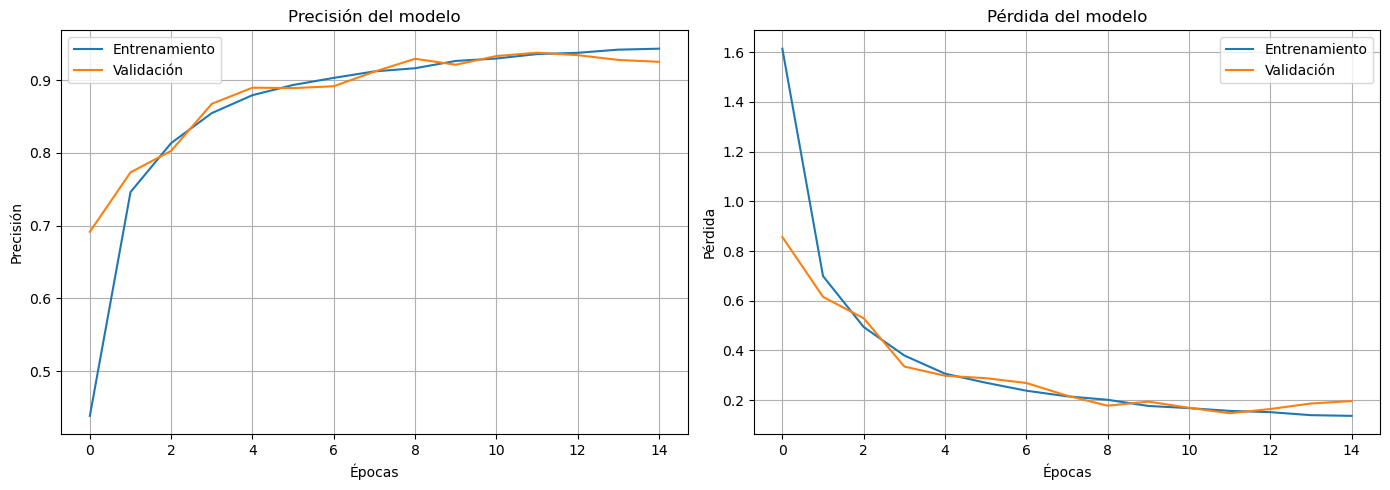

In [38]:
import matplotlib.pyplot as plt

# 1. Crear la figura
plt.figure(figsize=(14, 5))

# 2. Gráfico de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# 3. Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# 4. Mostrar
plt.tight_layout()
plt.show()


In [43]:
print(test.columns.tolist())

['Carpeta', 'image_id', 'Planta_Inglés', 'Estado_Ingles', 'Planta_Español', 'Estado_Español', 'Planta_Estado_Español']


In [46]:
epochs = list(range(1, 16))

loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']


data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

    Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0       1        1.614001         0.856400           0.438740   
1       2        0.699338         0.615776           0.746081   
2       3        0.494429         0.529689           0.813418   
3       4        0.379905         0.335504           0.854588   
4       5        0.306791         0.298453           0.879216   
5       6        0.270516         0.288630           0.893204   
6       7        0.238320         0.269293           0.902951   
7       8        0.215721         0.218399           0.911855   
8       9        0.201753         0.177989           0.916195   
9      10        0.176965         0.194349           0.926215   
10     11        0.168212         0.169506           0.929563   
11     12        0.157071         0.147576           0.935640   
12     13        0.152002         0.164602           0.937376   
13     14        0.139893         0.186775           0.941716   
14     15        0.137046

In [47]:
print('Perdida final en Train:', history.history['loss'][-1])
print("Pérdida final en Validation:", history.history['val_loss'][-1])

print("Accuracy final en Train:", history.history['accuracy'][-1])
print("Accuracy final en Validation:", history.history['val_accuracy'][-1])

Perdida final en Train: 0.13704551756381989
Pérdida final en Validation: 0.196558877825737
Accuracy final en Train: 0.9430307745933533
Accuracy final en Validation: 0.924992561340332


## 7. Testeo del Modelo

In [48]:
#validación con datos de test

test_generator = datagen.flow_from_dataframe(test,
                         directory = data_dir,
                         x_col = "image_id",
                         y_col = "Planta_Estado_Español",
                         target_size = (image_height,image_width),
                         batch_size = 1,
                         shuffle=False,
                         class_mode = "categorical")

Found 12601 validated image filenames belonging to 18 classes.


In [50]:
# Evaluar sobre el set de test
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator)) 

print(f'🔎 Pérdida en test: {test_loss:.4f}')
print(f'✅ Precisión en test: {test_accuracy:.2%}')


12601/12601 ━━━━━━━━━━━━━━━━━━━━ 385s 31ms/step - accuracy: 0.9435 - loss: 0.1375
🔎 Pérdida en test: 0.1498
✅ Precisión en test: 94.18%


In [51]:
# 1. Predecir clases sobre el test set
y_pred_probs = model.predict(test_generator)

# Convertir probabilidades a etiquetas (argmax)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Obtener etiquetas verdaderas
y_true = test_generator.classes

12601/12601 ━━━━━━━━━━━━━━━━━━━━ 388s 31ms/step


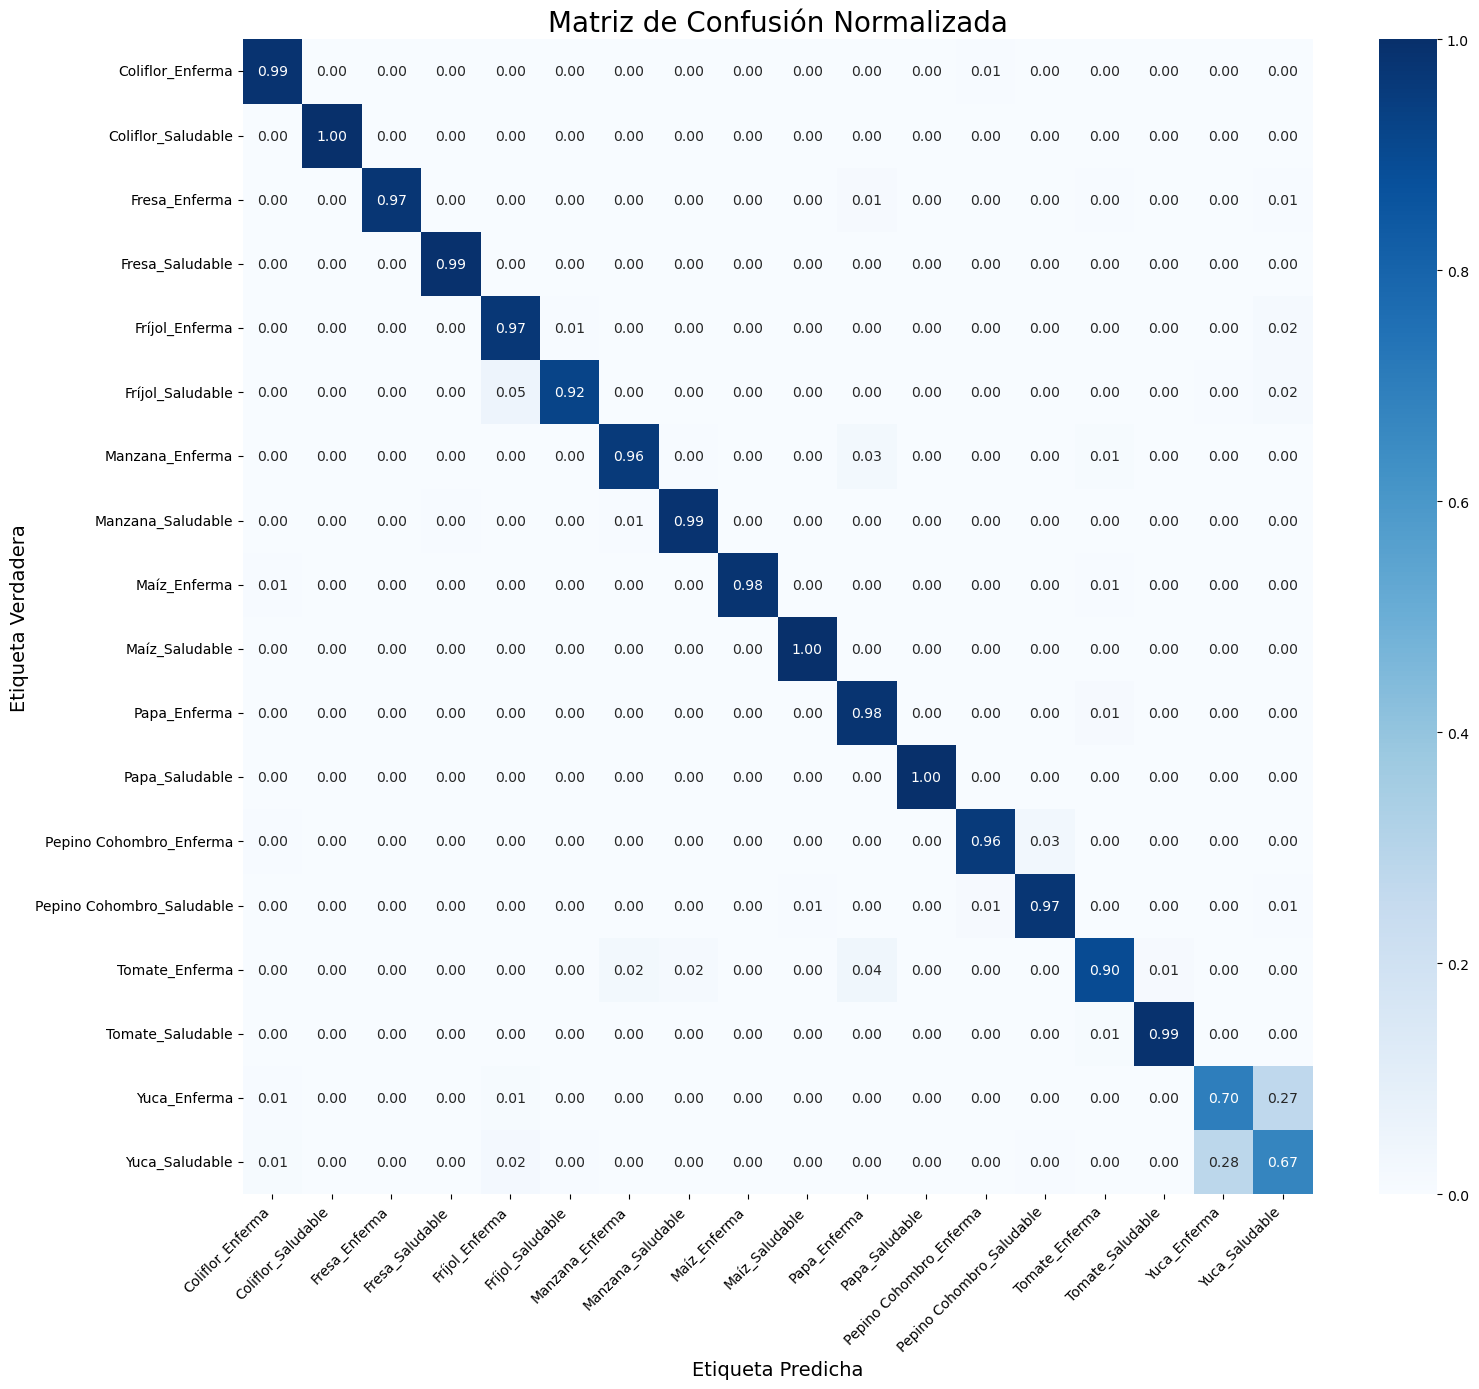


Reporte de Clasificación:
                           precision    recall  f1-score   support

         Coliflor_Enferma     0.9718    0.9857    0.9787       700
       Coliflor_Saludable     0.9943    1.0000    0.9972       700
            Fresa_Enferma     0.9971    0.9729    0.9848       700
          Fresa_Saludable     0.9943    0.9929    0.9936       700
           Fríjol_Enferma     0.9152    0.9714    0.9425       700
         Fríjol_Saludable     0.9878    0.9230    0.9543       701
          Manzana_Enferma     0.9683    0.9586    0.9634       700
        Manzana_Saludable     0.9732    0.9871    0.9801       700
             Maíz_Enferma     0.9971    0.9843    0.9907       700
           Maíz_Saludable     0.9929    0.9971    0.9950       700
             Papa_Enferma     0.9186    0.9829    0.9496       700
           Papa_Saludable     0.9972    1.0000    0.9986       700
  Pepino Cohombro_Enferma     0.9767    0.9600    0.9683       700
Pepino Cohombro_Saludable     0.96

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Predecir clases sobre el test set
# Obtener las predicciones del modelo
#y_pred_probs = model.predict(test_generator, steps=len(test_generator), verbose=1)

# Convertir probabilidades a etiquetas (argmax)
#_pred = np.argmax(y_pred_probs, axis=1)

# 2. Obtener etiquetas verdaderas
# Las verdaderas etiquetas están en test_generator.classes
#y_true = test_generator.classes

# 3. Obtener los nombres de las clases
class_labels = list(test_generator.class_indices.keys())

# 4. Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# 5. Normalizar la matriz de confusión (opcional para mejor visualización)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 6. Graficar la matriz de confusión
plt.figure(figsize=(16, 14))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusión Normalizada', fontsize=20)
plt.ylabel('Etiqueta Verdadera', fontsize=14)
plt.xlabel('Etiqueta Predicha', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Reporte de clasificación (precisión, recall, f1-score por clase)
print('\nReporte de Clasificación:')
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))


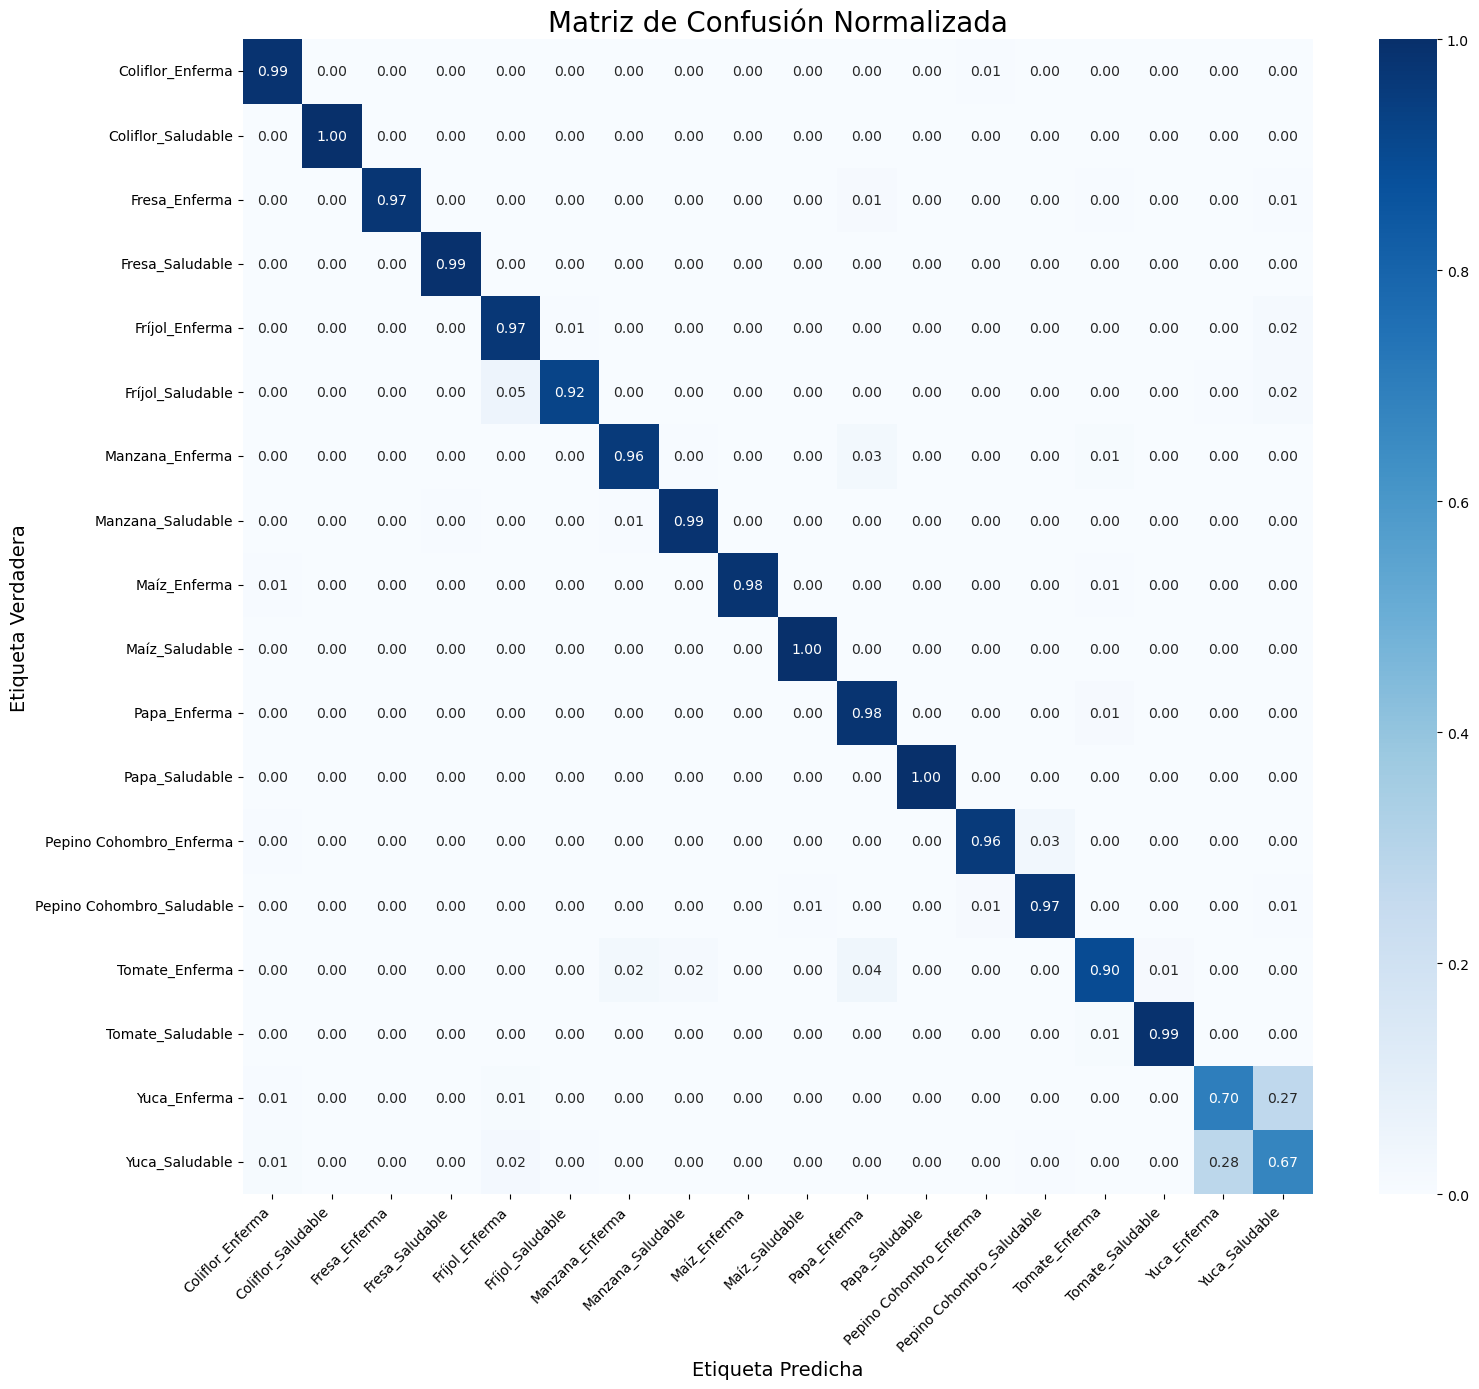

In [53]:
# 1. Guardar la figura de la matriz de confusión
plt.figure(figsize=(16, 14))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusión Normalizada', fontsize=20)
plt.ylabel('Etiqueta Verdadera', fontsize=14)
plt.xlabel('Etiqueta Predicha', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Guardar el gráfico como imagen
plt.savefig(r'C:\Proyecto de grado\Modelos\matriz_confusion.png', dpi=300)
plt.show()


In [54]:
# 2. Guardar el reporte de clasificación en CSV

# Convertir el reporte a un diccionario
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)

# Convertirlo a DataFrame
report_df = pd.DataFrame(report).transpose()

# Guardar como CSV
report_df.to_csv('reporte_clasificacion_modelo16_UNet_Planta_Estado_Balanceado_sin_DataAugmentation_100per.csv', index=True)

print("✅ Reporte de clasificación guardado")


✅ Reporte de clasificación guardado


In [55]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9418


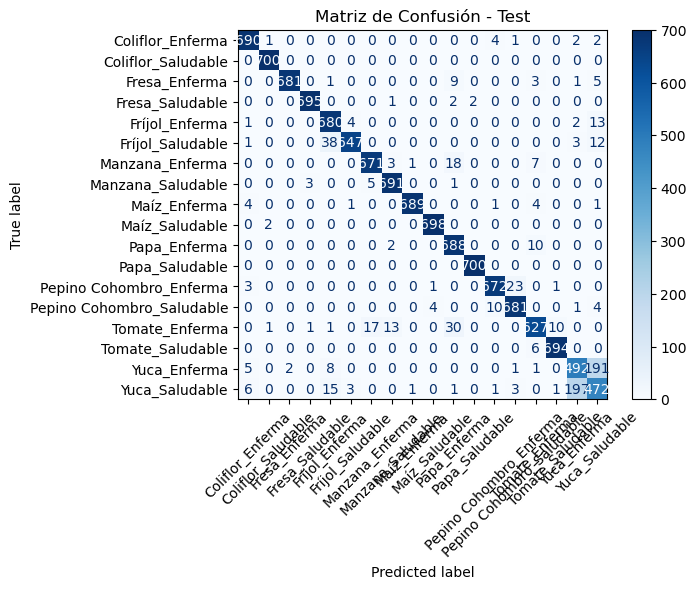

In [57]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión - Test")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


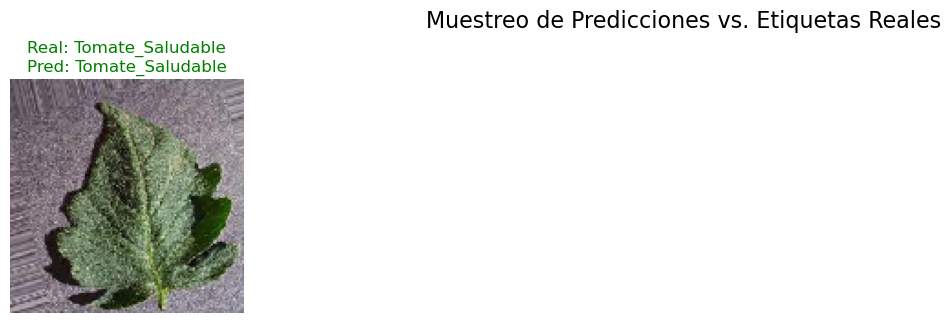

In [58]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

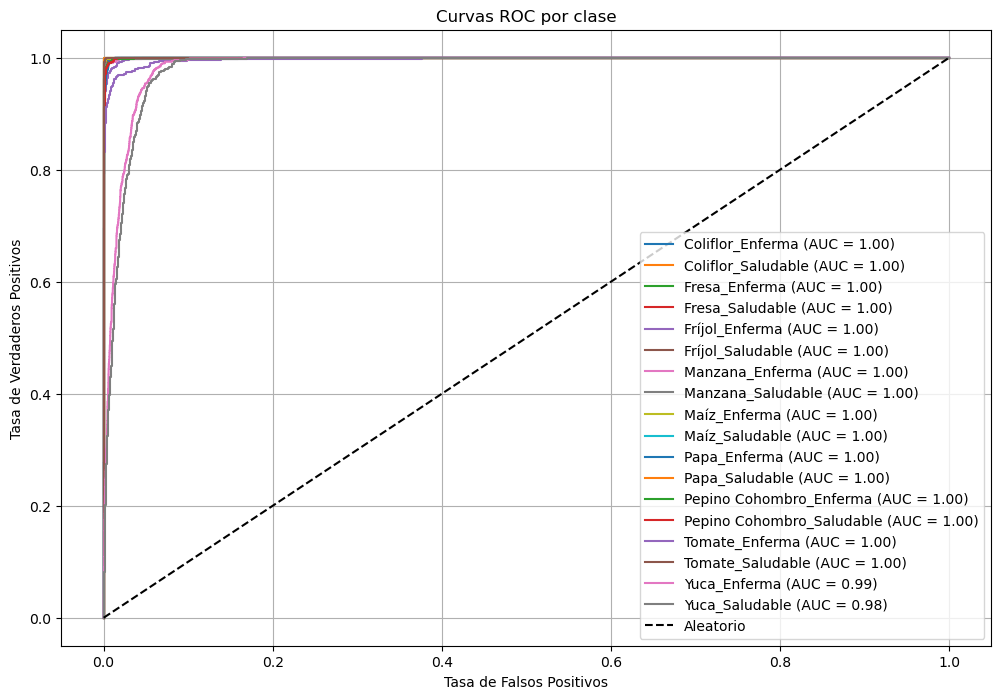

In [59]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [60]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


AUC Macro promedio: 0.9979
AUC Micro promedio: 0.9992


In [61]:
# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))

Accuracy: 0.9418
F1 Score (macro): 0.9418
F1 Score (micro): 0.9418
F1 Score (weighted): 0.9418

Reporte de clasificación por clase:
                           precision    recall  f1-score   support

         Coliflor_Enferma       0.97      0.99      0.98       700
       Coliflor_Saludable       0.99      1.00      1.00       700
            Fresa_Enferma       1.00      0.97      0.98       700
          Fresa_Saludable       0.99      0.99      0.99       700
           Fríjol_Enferma       0.92      0.97      0.94       700
         Fríjol_Saludable       0.99      0.92      0.95       701
          Manzana_Enferma       0.97      0.96      0.96       700
        Manzana_Saludable       0.97      0.99      0.98       700
             Maíz_Enferma       1.00      0.98      0.99       700
           Maíz_Saludable       0.99      1.00      1.00       700
             Papa_Enferma       0.92      0.98      0.95       700
           Papa_Saludable       1.00      1.00      1.00       

## 8. Guardar el modelo entrenado

In [63]:
model.save('modelo_16_Unet_PlantaEstado_Balanceado_Sin_Data_Aug_100perc.h5')

In [64]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-05-23 20:25:34.784052
Duración: 15:12:20.916767


In [65]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
print(index_to_class)
with open("index_to_class_modelo_16_Unet_PlantaEstado_Balanceado_Sin_Data_Aug_100perc.json", "w") as f:
    json.dump(index_to_class, f, indent=4, ensure_ascii=False)

{0: 'Coliflor_Enferma', 1: 'Coliflor_Saludable', 2: 'Fresa_Enferma', 3: 'Fresa_Saludable', 4: 'Fríjol_Enferma', 5: 'Fríjol_Saludable', 6: 'Manzana_Enferma', 7: 'Manzana_Saludable', 8: 'Maíz_Enferma', 9: 'Maíz_Saludable', 10: 'Papa_Enferma', 11: 'Papa_Saludable', 12: 'Pepino Cohombro_Enferma', 13: 'Pepino Cohombro_Saludable', 14: 'Tomate_Enferma', 15: 'Tomate_Saludable', 16: 'Yuca_Enferma', 17: 'Yuca_Saludable'}


In [89]:
#validación con datos de test

test_generator = datagen.flow_from_dataframe(test,
                         directory = data_dir,
                         x_col = "image_id",
                         y_col = "Planta_Estado_Español",
                         target_size = (image_height,image_width),
                         batch_size = 10,
                         shuffle=False,
                         class_mode = "categorical")

Found 12601 validated image filenames belonging to 18 classes.


Mostrando batch número: 1131
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


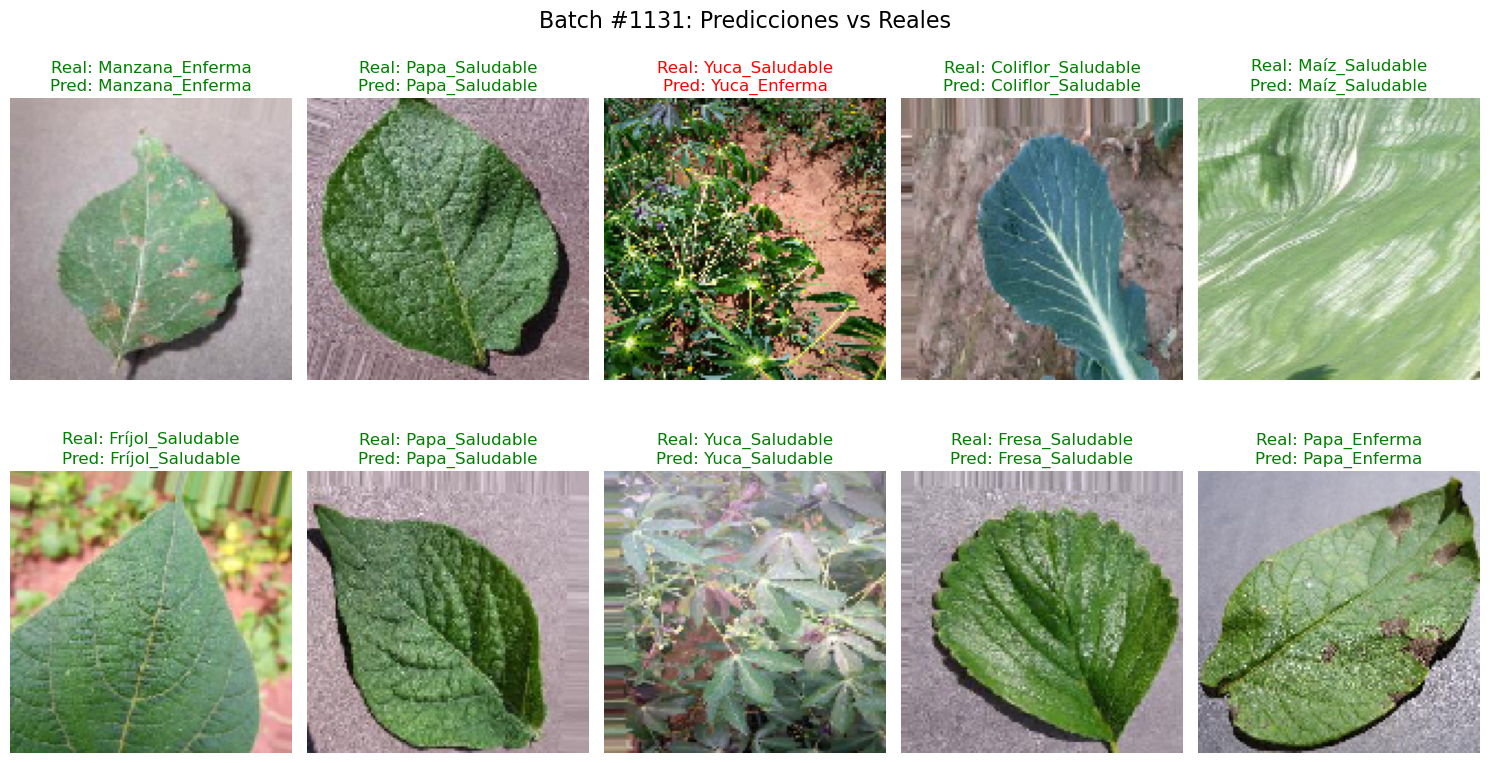

In [91]:
import random

# Obtener la cantidad total de batches
total_batches = len(test_generator)

# Seleccionar un número aleatorio de batch
batch_number = random.randint(0, total_batches - 1)
print(f"Mostrando batch número: {batch_number}")

# Obtener el batch aleatorio
x_batch, y_true_batch = test_generator[batch_number]

# Normalizar para visualización
x_batch = np.array([normalize_for_display(img) for img in x_batch])

# Obtener predicciones
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Mostrar imágenes con etiquetas
num_samples = x_batch.shape[0]
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_batch[i])
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle(f"Batch #{batch_number}: Predicciones vs Reales", fontsize=16, y=1.02)
plt.show()


Mostrando batch número: 429
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


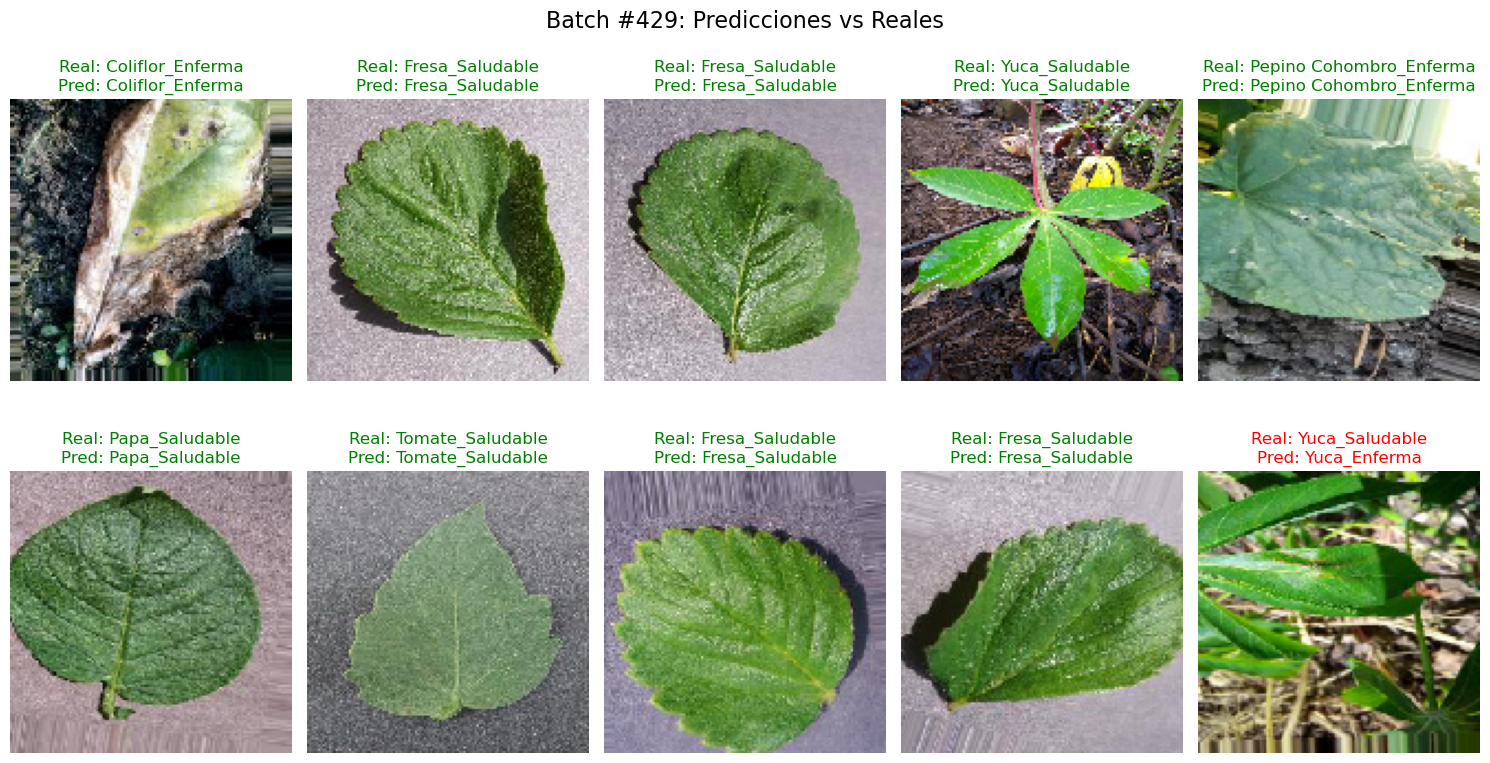

In [93]:
import random

# Obtener la cantidad total de batches
total_batches = len(test_generator)

# Seleccionar un número aleatorio de batch
batch_number = random.randint(0, total_batches - 1)
print(f"Mostrando batch número: {batch_number}")

# Obtener el batch aleatorio
x_batch, y_true_batch = test_generator[batch_number]

# Normalizar para visualización
x_batch = np.array([normalize_for_display(img) for img in x_batch])

# Obtener predicciones
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Mostrar imágenes con etiquetas
num_samples = x_batch.shape[0]
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_batch[i])
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle(f"Batch #{batch_number}: Predicciones vs Reales", fontsize=16, y=1.02)
plt.show()


Mostrando batch número: 472
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


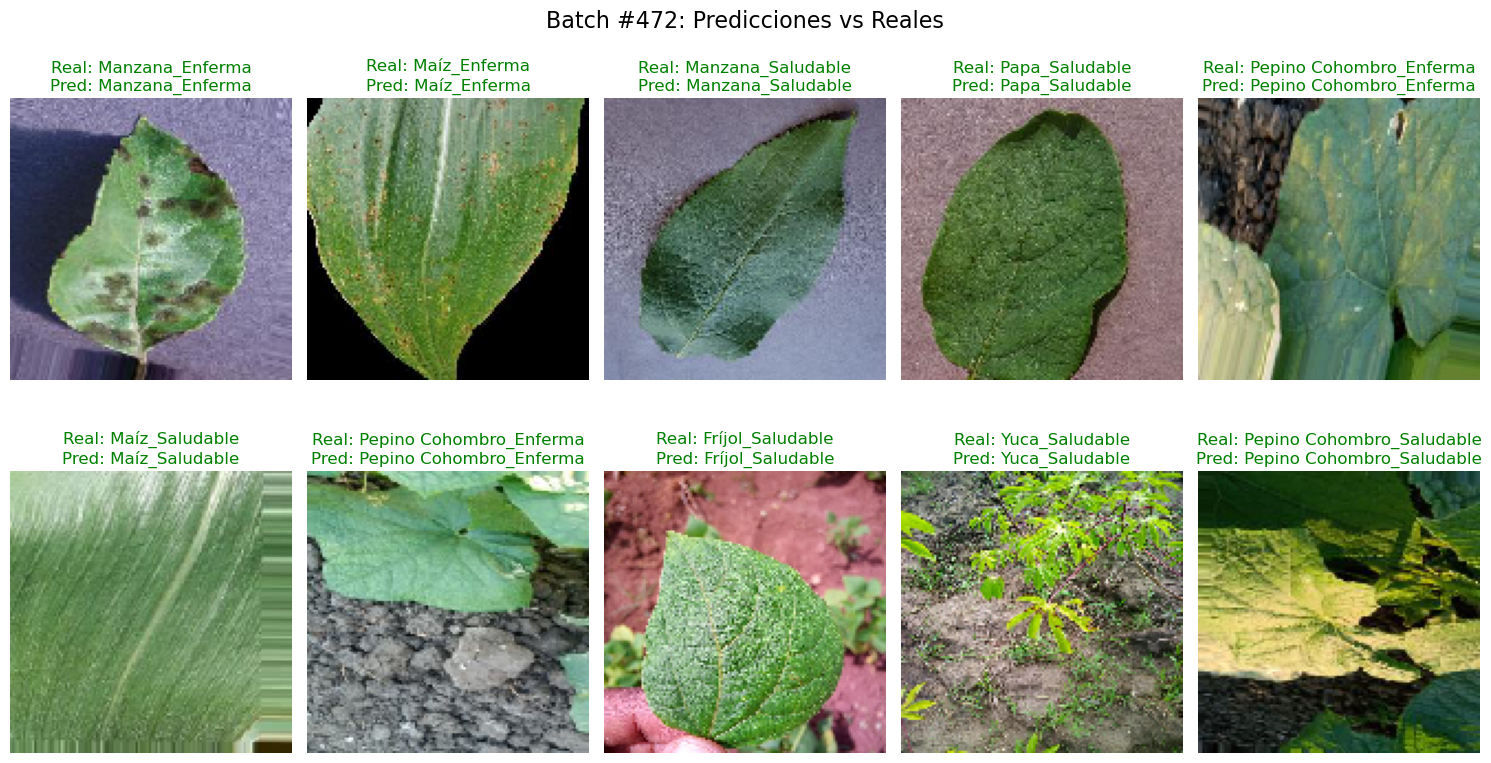

In [95]:
import random

# Obtener la cantidad total de batches
total_batches = len(test_generator)

# Seleccionar un número aleatorio de batch
batch_number = random.randint(0, total_batches - 1)
print(f"Mostrando batch número: {batch_number}")

# Obtener el batch aleatorio
x_batch, y_true_batch = test_generator[batch_number]

# Normalizar para visualización
x_batch = np.array([normalize_for_display(img) for img in x_batch])

# Obtener predicciones
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Mostrar imágenes con etiquetas
num_samples = x_batch.shape[0]
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_batch[i])
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle(f"Batch #{batch_number}: Predicciones vs Reales", fontsize=16, y=1.02)
plt.show()


Mostrando batch número: 246
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


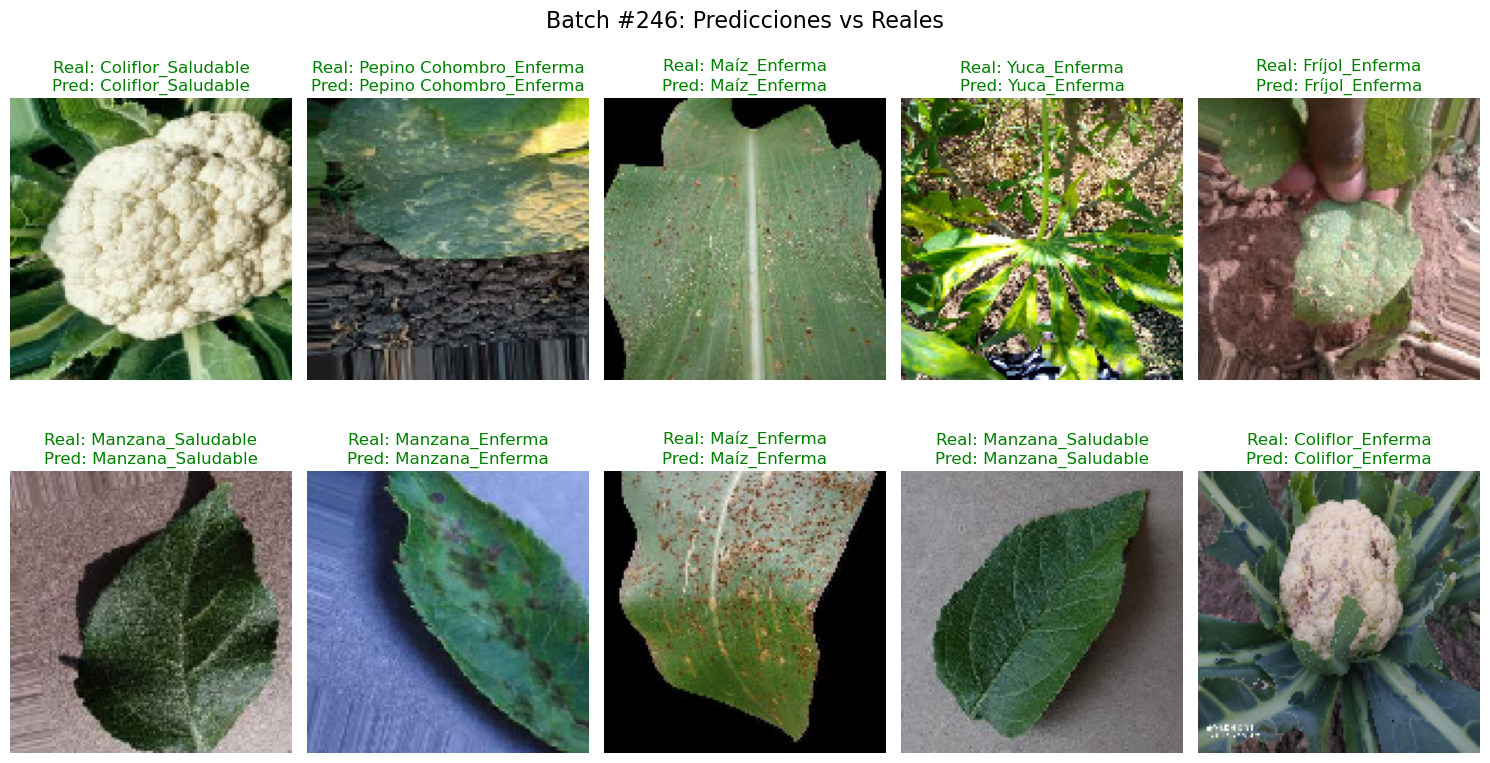

In [97]:
import random

# Obtener la cantidad total de batches
total_batches = len(test_generator)

# Seleccionar un número aleatorio de batch
batch_number = random.randint(0, total_batches - 1)
print(f"Mostrando batch número: {batch_number}")

# Obtener el batch aleatorio
x_batch, y_true_batch = test_generator[batch_number]

# Normalizar para visualización
x_batch = np.array([normalize_for_display(img) for img in x_batch])

# Obtener predicciones
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Mostrar imágenes con etiquetas
num_samples = x_batch.shape[0]
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_batch[i])
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle(f"Batch #{batch_number}: Predicciones vs Reales", fontsize=16, y=1.02)
plt.show()


In [129]:
# -------------------------
# Obtener predicciones completas en un json
# -------------------------

# Obtener nombres de archivo
file_names = test_generator.filenames

# Obtener clases del generador
class_indices = test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

# Crear la lista de resultados
results = []
for i in range(len(file_names)):
    pred_class_name = index_to_class[y_pred[i]]
    
    # Descomposición de la categoría en Planta y Estado 
    if "_" in pred_class_name:
        planta, condicion = pred_class_name.split("_",1)
    else:
        planta, condicion = pred_class_name, None

    result = {
        "archivo": file_names[i],
        "prediccion_clase": pred_class_name,
        "Planta": planta,
        "Condición": estado
    }
    results.append(result)

# Guardar a JSON
with open("resultados_modelo_16_Unet_PlantaEstado_Balanceado_Sin_Data_Aug_100perc.json", "w") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

Mostrando batch número: 1180
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step


ValueError: num must be an integer with 1 <= num <= 6, not 7

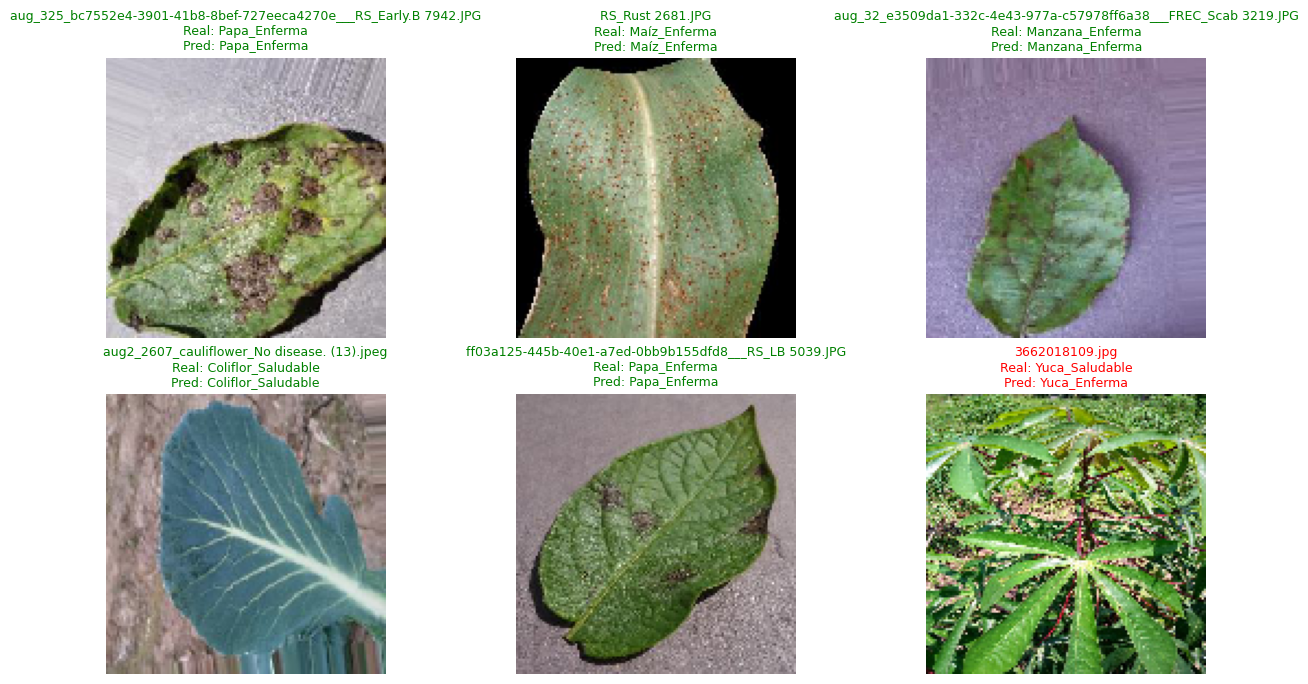

In [146]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Obtener la cantidad total de batches
total_batches = len(test_generator)

# Seleccionar un número aleatorio de batch
batch_number = random.randint(0, total_batches - 1)
print(f"Mostrando batch número: {batch_number}")

# Obtener el batch aleatorio
x_batch, y_true_batch = test_generator[batch_number]

# Normalizar para visualización
x_batch = np.array([normalize_for_display(img) for img in x_batch])

# Obtener predicciones
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Obtener nombres de archivo correspondientes al batch
start_idx = batch_number * test_generator.batch_size
end_idx = start_idx + len(x_batch)
file_names_batch = test_generator.filenames[start_idx:end_idx]

# Mostrar imágenes con etiquetas y nombres de archivo
num_samples = x_batch.shape[0]
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_batch[i])
    plt.axis('off')
    plt.title(
        f"{file_names_batch[i].split('/')[-1]}\n"
        f"Real: {class_names[y_true_batch[i]]}\n"
        f"Pred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red',
        fontsize=9
    )
plt.tight_layout()
plt.suptitle(f"Batch #{batch_number}: Predicciones vs Reales", fontsize=16, y=1.05)
plt.show()
